# Wetland Classification Pipeline

Interactive notebook for training and evaluating the U-Net wetland classifier.

## Workflow
1. **Setup** - Configure paths and parameters
2. **Compute Statistics** - Scan training data for normalization stats
3. **Explore Data** - Visualize samples and class distribution
4. **Train Model** - Run training loop
5. **Evaluate** - Test set metrics and confusion matrix
6. **Predict** - Apply to new rasters

## 1. Setup

In [1]:
# Imports
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
import torch

# Helper to import modules with numeric prefixes
# Checks sys.modules first to avoid duplicate imports (which break pickling)
def import_module(name, path):
    if name in sys.modules:
        return sys.modules[name]
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

# Get script directory
SCRIPT_DIR = Path.cwd()
if SCRIPT_DIR.name != "DL_Pipeline_v2":
    SCRIPT_DIR = Path.cwd() / "Python_Code_Analysis" / "DL_Pipeline_v2"

# Add script dir to path for band_utils import
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

# Project root
PROJECT_ROOT = SCRIPT_DIR.parent.parent

print(f"Script directory: {SCRIPT_DIR}")
print(f"Project root: {PROJECT_ROOT}")

Script directory: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Python_Code_Analysis/DL_Pipeline_v2
Project root: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL


In [2]:
# === CONFIGURATION ===
# Edit these paths and parameters as needed

# Data paths
PATCHES_DIR = PROJECT_ROOT / "Data" / "Training_Data" / "R_Patches"
STATS_PATH = PROJECT_ROOT / "Data" / "Training_Data" / "normalization_stats.json"
MODELS_DIR = PROJECT_ROOT / "Models"
REVIEW_LOG = PROJECT_ROOT / "Data" / "NWI_CHM_Review_Logs" / "review_log_AJS.csv"

# Training parameters
EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
BASE_FILTERS = 32  # 32 for local (M1), 64 for HPC
DEPTH = 4          # 4 for local, 5 for HPC
NUM_WORKERS = 4    # Set to 0 if you have issues on Mac
SEED = 42

print("Configuration loaded!")
print(f"Patches directory: {PATCHES_DIR}")
print(f"Patches exist: {PATCHES_DIR.exists()}")
print(f"Review log: {REVIEW_LOG}")
print(f"Review log exists: {REVIEW_LOG.exists()}")

Configuration loaded!
Patches directory: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/R_Patches
Patches exist: True
Review log: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/NWI_CHM_Review_Logs/review_log_AJS.csv
Review log exists: True


In [3]:
# Import pipeline modules
stats_module = import_module("compute_stats", SCRIPT_DIR / "01_compute_statistics.py")
dataset_module = import_module("dataset", SCRIPT_DIR / "02_dataset.py")
model_module = import_module("unet_model", SCRIPT_DIR / "03_unet_model.py")
train_module = import_module("train", SCRIPT_DIR / "04_train.py")
eval_module = import_module("evaluate", SCRIPT_DIR / "05_evaluate.py")

from band_utils import compute_in_channels_from_stats

print("Modules imported successfully!")

Modules imported successfully!


## 2. Compute Statistics

Scan all training patches to compute:
- Per-band min/max for normalization
- Class pixel counts for weighting

**Run this once** when you have new training data.

In [4]:
# Compute and save statistics
stats = stats_module.compute_statistics(PATCHES_DIR, STATS_PATH, review_log=REVIEW_LOG)

Review log: 695 accepted entries, 1494 patches excluded, 688 remaining
Found 688 patch files
Discovered 27 bands: ['DEM', 'meanc_local', 'planc_local', 'profc_local', 'dmv_local', 'slope_local', 'TPI_local', 'Geomorph_local', 'CHM', 'NDVI', 'MNDWI', 'EVI', 'NDYI', 'PSRI', 'GDVI', 'VV', 'VH', 'DPSVI', 'RVI', 'VH_VV_ratio', 'r', 'g', 'b', 'nir', 'n_ndvi', 'n_ndwi', 'MOD_CLASS']
Predictor bands: 26
Label band: 'MOD_CLASS' at index 26


Processing patches: 100%|████████████████████████████████████████████████████████████████████████████████████████| 688/688 [00:07<00:00, 93.77it/s]


Statistics saved to /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/normalization_stats.json

Summary:
  Patches: 688
  Total pixels: 11,272,192
  Labeled pixels: 5,255,211
  Unlabeled pixels (ignore_index=255): 6,016,981
  Predictor bands: 26
  Model input channels: 35
  Categorical classes found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Class distribution:
  EMW: 949,991 pixels (18.08%) - weight: 2.0275
  FSW: 1,926,089 pixels (36.65%) - weight: 1.0000
  OWW: 543,372 pixels (10.34%) - weight: 3.5447
  SSW: 721,647 pixels (13.73%) - weight: 2.6690
  UPL: 1,114,112 pixels (21.20%) - weight: 1.7288


In [5]:
# View computed statistics and set class config from stats
if STATS_PATH.exists():
    with open(STATS_PATH) as f:
        stats = json.load(f)
    
    # Extract class configuration from stats (used by cells below)
    CLASS_NAMES = stats["class_names"]
    NUM_CLASSES = len(CLASS_NAMES)
    IGNORE_INDEX = stats.get("ignore_index", 255)
    
    print("=== Normalization Statistics ===")
    print(f"Number of patches: {stats['num_patches']}")
    print(f"Total pixels: {stats['total_pixels']:,}")
    print(f"Input channels: {stats['in_channels']}")
    print(f"Classes: {CLASS_NAMES}")
    print(f"\nGeomorph classes found: {stats['geomorph_classes']}")
    
    print("\n=== Class Distribution ===")
    for name, count in stats['class_counts'].items():
        freq = stats['class_frequencies'][name]
        weight = stats['class_weights'][name]
        print(f"{name:12} {count:>12,} pixels ({freq*100:>6.2f}%) - weight: {weight:.4f}")
else:
    print("Statistics not computed yet. Run the cell above first.")

=== Normalization Statistics ===
Number of patches: 688
Total pixels: 11,272,192
Input channels: 35
Classes: ['EMW', 'FSW', 'OWW', 'SSW', 'UPL']

Geomorph classes found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

=== Class Distribution ===
EMW               949,991 pixels ( 18.08%) - weight: 2.0275
FSW             1,926,089 pixels ( 36.65%) - weight: 1.0000
OWW               543,372 pixels ( 10.34%) - weight: 3.5447
SSW               721,647 pixels ( 13.73%) - weight: 2.6690
UPL             1,114,112 pixels ( 21.20%) - weight: 1.7288


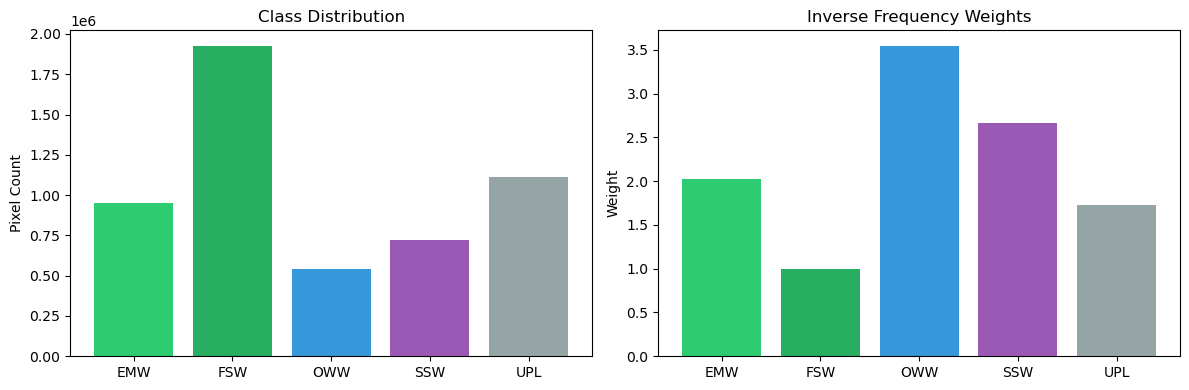

In [6]:
# Visualize class distribution
if STATS_PATH.exists():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Class counts
    counts = [stats['class_counts'].get(name, 0) for name in CLASS_NAMES]
    colors = ['#2ecc71', '#27ae60', '#3498db', '#9b59b6', '#95a5a6']
    
    axes[0].bar(CLASS_NAMES, counts, color=colors)
    axes[0].set_ylabel('Pixel Count')
    axes[0].set_title('Class Distribution')
    axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Class weights
    weights = [stats['class_weights'].get(name, 0) for name in CLASS_NAMES]
    axes[1].bar(CLASS_NAMES, weights, color=colors)
    axes[1].set_ylabel('Weight')
    axes[1].set_title('Inverse Frequency Weights')
    
    plt.tight_layout()
    plt.show()

## 3. Explore Data

Visualize sample patches and verify the data pipeline.

In [7]:
# Create data loaders
train_loader, val_loader, test_loader, class_weights = dataset_module.create_dataloaders(
    PATCHES_DIR, 
    STATS_PATH,
    batch_size=BATCH_SIZE,
    num_workers=0,  # Use 0 for notebook compatibility
    seed=SEED,
    review_log=REVIEW_LOG
)

print(f"\nClass weights: {class_weights}")

Review log: 695 accepted entries, 1494 patches excluded, 688 remaining
Data split (seed=42):
  Train: 481 patches (69.9%)
  Val:   103 patches (15.0%)
  Test:  104 patches (15.1%)

Class weights: tensor([2.0275, 1.0000, 3.5447, 2.6690, 1.7288])


In [8]:
# Get a sample batch
X_sample, y_sample = next(iter(train_loader))

in_channels = compute_in_channels_from_stats(STATS_PATH)

print(f"Input shape: {X_sample.shape} (expected: [batch, {in_channels}, 128, 128])")
print(f"Label shape: {y_sample.shape}")
print(f"Input range: [{X_sample.min():.3f}, {X_sample.max():.3f}]")
print(f"Label classes: {torch.unique(y_sample).tolist()}")

Input shape: torch.Size([16, 35, 128, 128]) (expected: [batch, 35, 128, 128])
Label shape: torch.Size([16, 128, 128])
Input range: [0.000, 1.000]
Label classes: [0, 1, 2, 3, 4, 255]


/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [9]:
X_sample.shape

torch.Size([16, 35, 128, 128])

In [10]:
import rasterio 
patch_file = '/Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/R_Patches/cluster_64_huc_041300030205_patch_47.tif'
with rasterio.open(patch_file) as src:
    data = src.read
    desc = src.descriptions

desc

('DEM',
 'meanc_local',
 'planc_local',
 'profc_local',
 'dmv_local',
 'slope_local',
 'TPI_local',
 'Geomorph_local',
 'CHM',
 'NDVI',
 'MNDWI',
 'EVI',
 'NDYI',
 'PSRI',
 'GDVI',
 'VV',
 'VH',
 'DPSVI',
 'RVI',
 'VH_VV_ratio',
 'r',
 'g',
 'b',
 'nir',
 'n_ndvi',
 'n_ndwi',
 'MOD_CLASS')

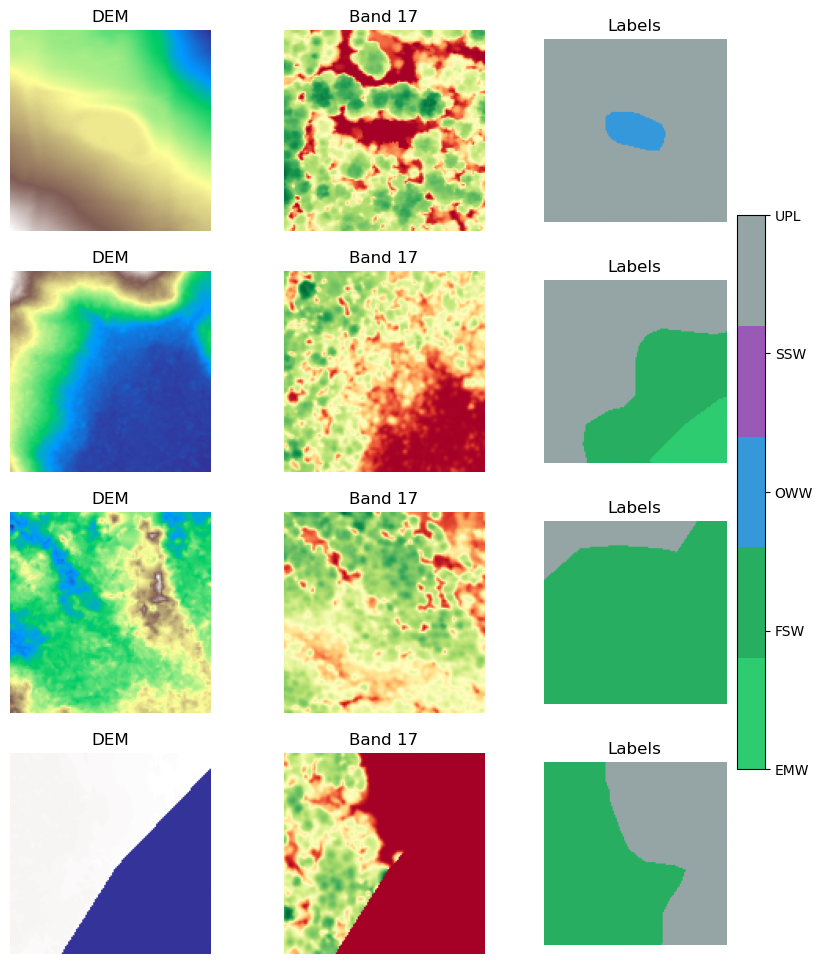

In [11]:
# Visualize sample patches
def plot_samples(X, y, n_samples=4):
    """Plot sample patches with their labels."""
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3*n_samples))
    
    # Color map for classes
    cmap_labels = plt.cm.colors.ListedColormap(['#2ecc71', '#27ae60', '#3498db', '#9b59b6', '#95a5a6'])
    
    for i in range(min(n_samples, X.shape[0])):
        # NDVI (band 9 in original, after one-hot it's different)
        # First 7 continuous bands, then 10 one-hot, then remaining continuous
        # NDVI was band 9, so after one-hot: 7 + 10 + (9-8) = 18
        ndvi_idx = 17  # Approximate - depends on exact ordering
        
        # Use first band (DEM) for visualization
        axes[i, 0].imshow(X[i, 0].numpy(), cmap='terrain')
        axes[i, 0].set_title('DEM')
        axes[i, 0].axis('off')
        
        # NDVI-like visualization (using a middle band)
        axes[i, 1].imshow(X[i, ndvi_idx].numpy(), cmap='RdYlGn')
        axes[i, 1].set_title(f'Band {ndvi_idx}')
        axes[i, 1].axis('off')
        
        # Labels
        im = axes[i, 2].imshow(y[i].numpy(), cmap=cmap_labels, vmin=0, vmax=4)
        axes[i, 2].set_title('Labels')
        axes[i, 2].axis('off')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[:, 2].tolist(), shrink=0.6)
    cbar.set_ticks([0, 1, 2, 3, 4])
    cbar.set_ticklabels(CLASS_NAMES)
    
    # plt.tight_layout()
    plt.show()

plot_samples(X_sample, y_sample)

## 4. Train Model

Train the U-Net model on the training set.

In [12]:
# Get training device
device = model_module.get_device()
print(f"Using device: {device}")

Using device: mps


In [13]:
# Preview model architecture (optional — training creates its own model)
in_channels = compute_in_channels_from_stats(STATS_PATH)

model_module.create_model(
    in_channels=in_channels,
    num_classes=NUM_CLASSES,
    base_filters=BASE_FILTERS,
    depth=DEPTH,
    device=device
)

Created U-Net model:
  Input channels: 35
  Output classes: 5
  Base filters: 32
  Depth: 4
  Parameters: 7,772,389
  Device: mps


UNet(
  (encoders): ModuleList(
    (0): EncoderBlock(
      (conv): ConvBlock(
        (block): Sequential(
          (0): Conv2d(35, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncoderBlock(
      (conv): ConvBlock(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kerne

In [14]:
# === RUN TRAINING (calls 04_train.py) ===
# Handles: dataloaders, model creation, optimizer, scheduler, checkpointing
history = train_module.train(
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    output_dir=MODELS_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    base_filters=BASE_FILTERS,
    depth=DEPTH,
    num_workers=0,
    seed=SEED,
    device=device,
    review_log=REVIEW_LOG
)

Wetland Classification Training
Device: mps
Patches: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/R_Patches
Output: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models
Epochs: 50, Batch size: 16, LR: 0.0001
Input channels: 35, Classes: 5

Loading data...
Review log: 695 accepted entries, 1494 patches excluded, 688 remaining
Data split (seed=42):
  Train: 481 patches (69.9%)
  Val:   103 patches (15.0%)
  Test:  104 patches (15.1%)

Class weights: [2.0275 1.     3.5447 2.669  1.7288]

Initializing model...
Created U-Net model:
  Input channels: 35
  Output classes: 5
  Base filters: 32
  Depth: 4
  Parameters: 7,772,389
  Device: mps

Starting training at 2026-02-12 16:22:43

Epoch 1/50 (LR: 1.00e-04)
----------------------------------------


/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


  Train - Loss: 1.4629, Acc: 0.3595, mIoU: 0.1576
  Val   - Loss: 1.5215, Acc: 0.3190, mIoU: 0.1613
  Time: 14.3s
  *** Saved best model (val_loss: 1.5215) ***

Epoch 2/50 (LR: 1.00e-04)
----------------------------------------
  Train - Loss: 1.2459, Acc: 0.4961, mIoU: 0.2777
  Val   - Loss: 1.3375, Acc: 0.4702, mIoU: 0.2446
  Time: 9.5s
  *** Saved best model (val_loss: 1.3375) ***

Epoch 3/50 (LR: 1.00e-04)
----------------------------------------
  Train - Loss: 1.1860, Acc: 0.5978, mIoU: 0.3606
  Val   - Loss: 1.2228, Acc: 0.5613, mIoU: 0.3144
  Time: 9.4s
  *** Saved best model (val_loss: 1.2228) ***

Epoch 4/50 (LR: 1.00e-04)
----------------------------------------
  Train - Loss: 1.1425, Acc: 0.6324, mIoU: 0.4106
  Val   - Loss: 1.1571, Acc: 0.6213, mIoU: 0.3618
  Time: 9.5s
  *** Saved best model (val_loss: 1.1571) ***

Epoch 5/50 (LR: 1.00e-04)
----------------------------------------
  Train - Loss: 1.0755, Acc: 0.6475, mIoU: 0.4188
  Val   - Loss: 1.1698, Acc: 0.6512, mIoU

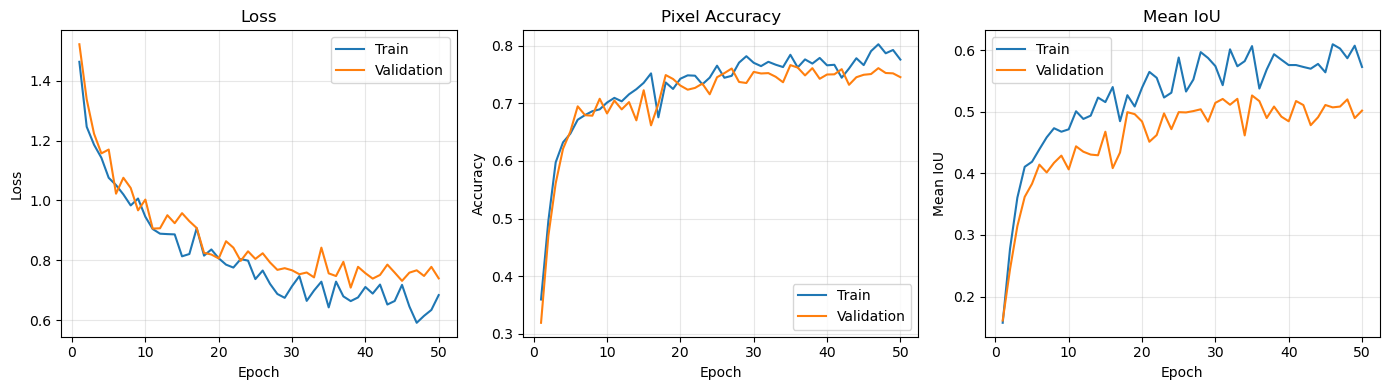

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_accuracy'], label='Train')
axes[1].plot(epochs_range, history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Pixel Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# IoU
axes[2].plot(epochs_range, history['train_iou'], label='Train')
axes[2].plot(epochs_range, history['val_iou'], label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Mean IoU')
axes[2].set_title('Mean IoU')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_curves.png', dpi=150)
plt.show()

## 5. Evaluate Model

Evaluate the best model on the held-out test set.

In [18]:
# Load best model and create test loader (calls 05_evaluate.py)
device = model_module.get_device()
in_channels = compute_in_channels_from_stats(STATS_PATH)

# Recreate test loader (same seed = same split)
_, _, test_loader, _ = dataset_module.create_dataloaders(
    PATCHES_DIR, STATS_PATH,
    batch_size=BATCH_SIZE,
    num_workers=0,  # Use 0 for notebook compatibility
    seed=SEED,
    review_log=REVIEW_LOG
)

model = eval_module.load_model(
    MODELS_DIR / 'best_model.pth',
    device=device,
    in_channels=in_channels,
    num_classes=NUM_CLASSES,
    base_filters=BASE_FILTERS,
    depth=DEPTH
)

Review log: 695 accepted entries, 1494 patches excluded, 688 remaining
Data split (seed=42):
  Train: 481 patches (69.9%)
  Val:   103 patches (15.0%)
  Test:  104 patches (15.1%)
Loaded model from /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models/best_model.pth
  Epoch: 37
  Val loss: 0.7088


In [19]:
# Evaluate on test set (calls 05_evaluate.py)
metrics = eval_module.evaluate(
    model, test_loader, device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    class_names=CLASS_NAMES
)

eval_module.print_metrics(metrics, CLASS_NAMES)

Running inference...
  Total pixels: 1,703,936, Labeled: 815,665, Unlabeled: 888,271
Computing metrics...

Evaluation Results

Overall Accuracy: 0.7600
Mean IoU: 0.6149
Macro F1: 0.7483

Per-Class Metrics:
------------------------------------------------------------
Class         Precision     Recall         F1        IoU    Support
------------------------------------------------------------
EMW              0.6886     0.6905     0.6896     0.5262    191,343
FSW              0.9338     0.7706     0.8444     0.7307    272,288
OWW              0.6522     0.8725     0.7465     0.5955     81,510
SSW              0.4988     0.5938     0.5422     0.3719    123,068
UPL              0.9315     0.9069     0.9190     0.8502    147,456
------------------------------------------------------------

Confusion Matrix:
                 EMW     FSW     OWW     SSW     UPL
EMW          132,120   2,011  21,436  32,853   2,923
FSW           11,611 209,836   7,982  38,331   4,528
OWW            7,168   1,

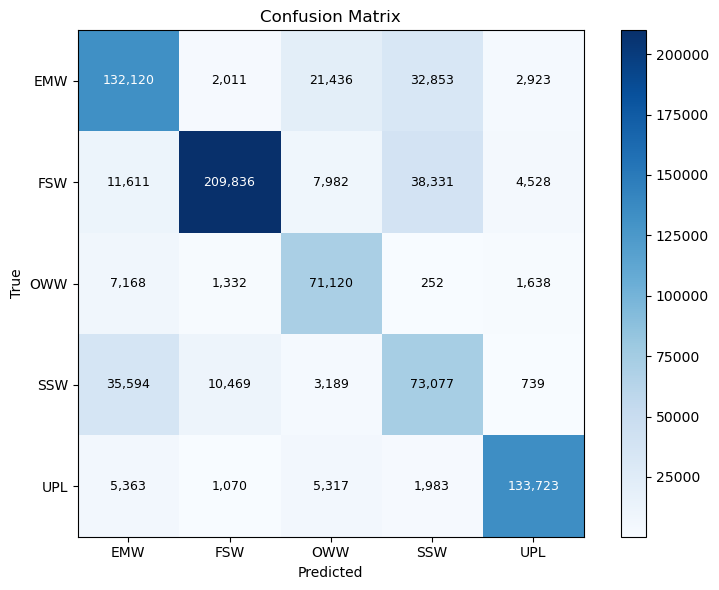

In [25]:
# Plot confusion matrix
cm = np.array(metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

# Add text annotations
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        val = cm[i, j]
        color = 'white' if val > cm.max() / 2 else 'black'
        ax.text(j, i, f'{val:,}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


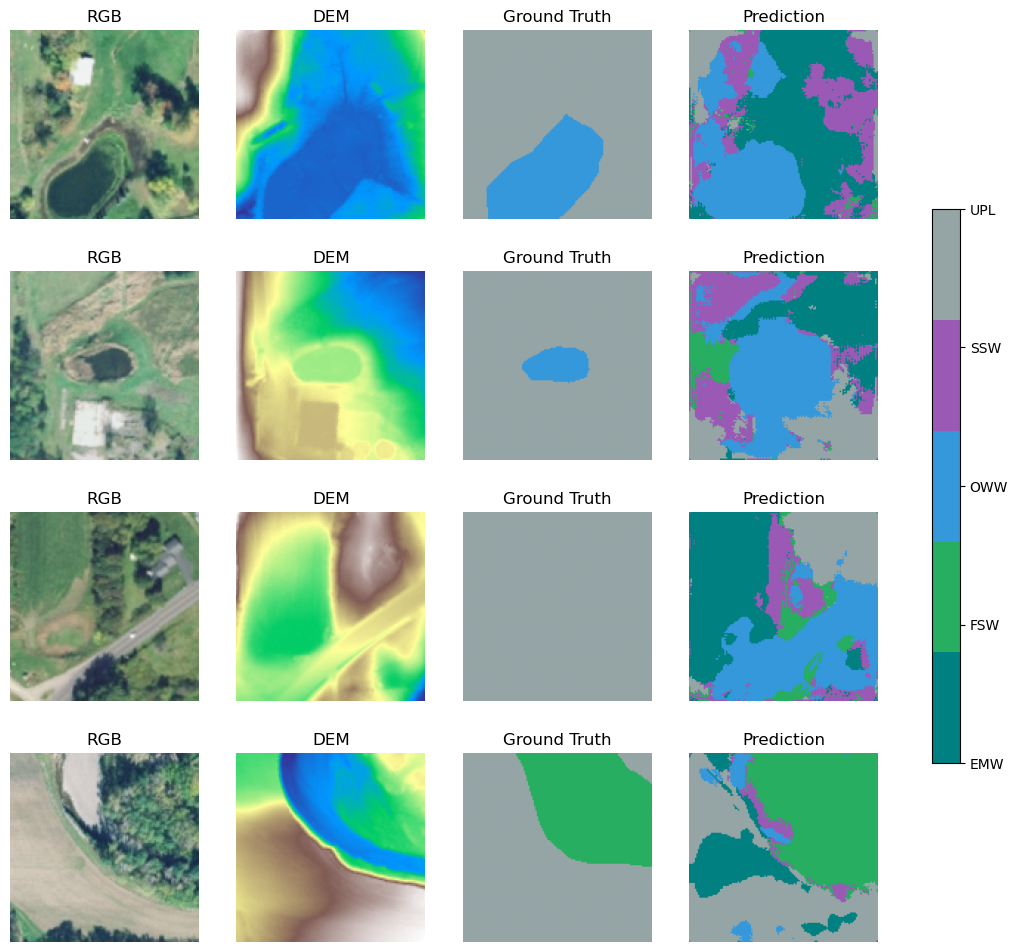

In [29]:
# Visualize predictions on test samples
X_test, y_test = next(iter(test_loader))
X_test_dev = X_test.to(device)

with torch.no_grad():
    preds = model(X_test_dev).argmax(dim=1).cpu()

# Find RGB channel indices in the normalized tensor.
# Bands are output in predictor_names order, but Geomorph_local expands
# to 10 one-hot channels, so we need to account for that offset.
rgb_indices = []
ch = 0
for name in stats["predictor_names"]:
    method = stats["normalization"][name]["method"]
    if name in ("r", "g", "b"):
        rgb_indices.append(ch)
    if method == "one_hot":
        ch += stats["normalization"][name]["num_classes"]
    else:
        ch += 1

# Plot: RGB | DEM | Ground Truth | Prediction
n_samples = 4
fig, axes = plt.subplots(n_samples, 4, figsize=(14, 3 * n_samples))
cmap = plt.cm.colors.ListedColormap(['#008080', '#27ae60', '#3498db', '#9b59b6', '#95a5a6'])

for i in range(n_samples):
    # RGB composite (already normalized to [0, 1])
    rgb = X_test[i, rgb_indices].numpy().transpose(1, 2, 0)
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title('RGB')
    axes[i, 0].axis('off')

    # DEM
    axes[i, 1].imshow(X_test[i, 0].cpu().numpy(), cmap='terrain')
    axes[i, 1].set_title('DEM')
    axes[i, 1].axis('off')

    # Ground truth
    axes[i, 2].imshow(y_test[i].numpy(), cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title('Ground Truth')
    axes[i, 2].axis('off')

    # Prediction
    im = axes[i, 3].imshow(preds[i].numpy(), cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 3].set_title('Prediction')
    axes[i, 3].axis('off')

# Legend
cbar = plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(CLASS_NAMES)

# plt.tight_layout()
plt.savefig(MODELS_DIR / 'test_predictions.png', dpi=150)
plt.show()

## 6. Predict on New Rasters

Apply the trained model to full rasters.

In [ ]:
# Import prediction module
predict_module = import_module("predict", SCRIPT_DIR / "06_predict.py")

In [ ]:
# === Configure prediction ===
# Set the input raster path (must have 20+ bands in correct order)
INPUT_RASTER = PROJECT_ROOT / "Data" / "path_to_your_raster.tif"  # <-- EDIT THIS
OUTPUT_RASTER = PROJECT_ROOT / "Data" / "Predictions" / "prediction.tif"

# Prediction settings
PATCH_SIZE = 128
OVERLAP = 32  # Overlap for smoother predictions
SAVE_PROBS = True  # Save probability maps

In [ ]:
# Run prediction (uncomment when ready)
# predict_module.main(
#     model_path=MODELS_DIR / 'best_model.pth',
#     input_path=INPUT_RASTER,
#     output_path=OUTPUT_RASTER,
#     stats_path=STATS_PATH,
#     patch_size=PATCH_SIZE,
#     overlap=OVERLAP,
#     base_filters=BASE_FILTERS,
#     depth=DEPTH,
#     save_probabilities=SAVE_PROBS
# )

## Summary

This notebook provides an interactive interface to:
1. Compute normalization statistics from training data
2. Explore and visualize the data
3. Train a U-Net model with class weighting
4. Evaluate on a held-out test set
5. Generate predictions on new rasters

### Files Generated
- `Data/Training_Data/normalization_stats.json` - Band statistics and class weights
- `Models/best_model.pth` - Best model checkpoint
- `Models/final_model.pth` - Final model checkpoint  
- `Models/training_history.json` - Training metrics
- `Models/training_curves.png` - Loss/accuracy plots
- `Models/confusion_matrix.png` - Confusion matrix visualization
- `Models/test_predictions.png` - Sample predictions